# 1. Imports and Setup

In [103]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from gensim.models import Word2Vec

# 2. Data Loading & Unified Preprocessing

In [104]:
fake = pd.read_csv("News_dataset/Fake.csv")
true = pd.read_csv("News_dataset/True.csv")

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

label_names = {0: "Fake News", 1: "True News"}

print("Dataset Shape:", df.shape)
print("Label Distribution:\n", df['label'].value_counts())

Dataset Shape: (44898, 5)
Label Distribution:
 label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    text = re.sub(r'<.*?>', ' ', text)
    
    text = re.sub(r'^.*?\(reuters\)\s*-\s*', '', text)
    text = re.sub(r'^.*?\breuters\b\s*-\s*', '', text)
    
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df['clean_text'] = df['content'].apply(clean_text)

df[['content', 'clean_text', 'label']].head()

# 3. Train / Test Split

In [ ]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 35918
Testing rows: 8980


# 4. Feature Extraction

### 1. Count Vectorizer

In [ ]:
count_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=10000
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

In [ ]:
print("Training data :", X_train_count)

Training data : <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5332300 stored elements and shape (35918, 10000)>
  Coords	Values
  (0, 7852)	2
  (0, 9551)	1
  (0, 2644)	2
  (0, 4687)	1
  (0, 4048)	1
  (0, 5389)	1
  (0, 1433)	1
  (0, 2800)	2
  (0, 9742)	1
  (0, 7337)	1
  (0, 9887)	1
  (0, 7106)	2
  (0, 934)	1
  (0, 6355)	1
  (0, 4727)	1
  (0, 5503)	1
  (0, 808)	1
  (0, 1556)	2
  (0, 1073)	2
  (0, 2289)	1
  (0, 4358)	1
  (0, 5461)	1
  (0, 7633)	1
  (0, 933)	1
  (0, 5969)	1
  :	:
  (35917, 3527)	1
  (35917, 613)	1
  (35917, 6292)	2
  (35917, 126)	1
  (35917, 4805)	1
  (35917, 2080)	1
  (35917, 7632)	1
  (35917, 387)	1
  (35917, 1824)	1
  (35917, 5312)	1
  (35917, 7268)	1
  (35917, 7809)	1
  (35917, 1964)	1
  (35917, 3836)	1
  (35917, 7999)	1
  (35917, 7697)	1
  (35917, 9846)	1
  (35917, 3658)	1
  (35917, 7352)	1
  (35917, 7847)	1
  (35917, 3961)	1
  (35917, 1056)	1
  (35917, 5267)	1
  (35917, 4872)	1
  (35917, 3660)	1


In [ ]:
print("Testing data :", X_test_count)

Testing data : <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1309477 stored elements and shape (8980, 10000)>
  Coords	Values
  (0, 28)	1
  (0, 52)	4
  (0, 67)	1
  (0, 74)	1
  (0, 112)	1
  (0, 214)	4
  (0, 292)	1
  (0, 297)	1
  (0, 332)	1
  (0, 481)	3
  (0, 508)	1
  (0, 509)	1
  (0, 521)	2
  (0, 594)	3
  (0, 599)	3
  (0, 635)	4
  (0, 662)	1
  (0, 757)	1
  (0, 946)	2
  (0, 1085)	1
  (0, 1086)	1
  (0, 1153)	1
  (0, 1158)	1
  (0, 1175)	1
  (0, 1213)	2
  :	:
  (8979, 8616)	1
  (8979, 8621)	2
  (8979, 8662)	1
  (8979, 8855)	1
  (8979, 8918)	1
  (8979, 8919)	1
  (8979, 8934)	1
  (8979, 8986)	2
  (8979, 9046)	1
  (8979, 9047)	2
  (8979, 9111)	1
  (8979, 9124)	1
  (8979, 9139)	1
  (8979, 9157)	3
  (8979, 9324)	1
  (8979, 9376)	1
  (8979, 9422)	1
  (8979, 9426)	1
  (8979, 9514)	1
  (8979, 9555)	2
  (8979, 9557)	1
  (8979, 9700)	1
  (8979, 9705)	1
  (8979, 9820)	1
  (8979, 9895)	1


### 2. TF-IDF Vectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=10000,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
print("Training data :", X_train_tfidf)

Training data : <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5332300 stored elements and shape (35918, 10000)>
  Coords	Values
  (0, 7852)	0.22358119828134396
  (0, 9551)	0.1131720132731473
  (0, 2644)	0.2933295483875737
  (0, 4687)	0.09055012052652624
  (0, 4048)	0.10518863213883134
  (0, 5389)	0.10920402737442461
  (0, 1433)	0.08414224360836906
  (0, 2800)	0.19327696053797155
  (0, 9742)	0.07259123156288072
  (0, 7337)	0.1431280842155565
  (0, 9887)	0.10622350842818318
  (0, 7106)	0.2658910801169586
  (0, 934)	0.1140440985452187
  (0, 6355)	0.08864705607156803
  (0, 4727)	0.0847637482950703
  (0, 5503)	0.13445574464329807
  (0, 808)	0.1694941765249113
  (0, 1556)	0.2517082792510655
  (0, 1073)	0.24290309767142546
  (0, 2289)	0.10665907335958598
  (0, 4358)	0.13513016383115165
  (0, 5461)	0.07956898517814391
  (0, 7633)	0.03401991899276626
  (0, 933)	0.13919021158508985
  (0, 5969)	0.0700581379814612
  :	:
  (35917, 3527)	0.10881223479102492
  (35917, 613)	0.150936693

In [ ]:
print("Testing data :", X_test_tfidf)

Testing data : <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1309477 stored elements and shape (8980, 10000)>
  Coords	Values
  (0, 28)	0.06939181142308219
  (0, 52)	0.06946809611633255
  (0, 67)	0.05377224365370324
  (0, 74)	0.04099533502970437
  (0, 112)	0.057032077172239536
  (0, 214)	0.13946637440997964
  (0, 292)	0.046825797975869735
  (0, 297)	0.07191936560417442
  (0, 332)	0.029215506621831085
  (0, 481)	0.09543491469687353
  (0, 508)	0.048090632570849695
  (0, 509)	0.06542666062664883
  (0, 521)	0.0809462701813267
  (0, 594)	0.08070925436239242
  (0, 599)	0.08452436240637619
  (0, 635)	0.10534435940535844
  (0, 662)	0.03760192829072918
  (0, 757)	0.06905162660657804
  (0, 946)	0.09392979026169027
  (0, 1085)	0.05379761352690004
  (0, 1086)	0.06374022548105314
  (0, 1153)	0.06488091784039657
  (0, 1158)	0.06374022548105314
  (0, 1175)	0.04421708660271595
  (0, 1213)	0.09012253865849461
  :	:
  (8979, 8616)	0.07266715051681591
  (8979, 8621)	0.14007707000893266
  

### 3. Word2Vec

In [ ]:
train_words = X_train.str.split()
test_words = X_test.str.split()

w2v_model = Word2Vec(
    sentences=train_words.tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    epochs=15,
    seed=42
)

def get_average_vector(words, model):
    word_vectors = [model.wv[w] for w in words if w in model.wv]
    if len(word_vectors) == 0:
        return np.zeros(100)
    return np.mean(word_vectors, axis=0)

X_train_w2v = np.array([get_average_vector(words, w2v_model) for words in train_words])
X_test_w2v = np.array([get_average_vector(words, w2v_model) for words in test_words])

print("Vocabulary size    :", len(w2v_model.wv))

Vocabulary size    : 68538


In [ ]:
print("Training data :", X_train_w2v)

Training data : [[ 0.05243063 -0.48649874  0.09678476 ...  0.05798421  0.93767565
  -0.51698995]
 [-0.02244324 -0.25160989  0.36223447 ...  0.09078815  0.9223066
   0.13337016]
 [ 0.08226775 -0.10427035  0.66380495 ...  0.18754487  0.45889005
  -0.53116357]
 ...
 [-0.06766259 -0.27843904  0.54095715 ...  0.5980953   0.41592684
  -0.53438675]
 [-0.34014842 -0.72058105  0.85954821 ...  0.07253319  0.4464004
  -0.53598928]
 [-0.00509554 -0.17329684  0.61261421 ...  0.34442517  0.12888275
  -0.24249281]]


In [ ]:
print("Testing data :", X_test_w2v)

Testing data : [[-0.0853485  -0.20959812  0.02358997 ...  0.0322666   0.37075725
  -0.00927784]
 [-0.04383387 -0.45162204  0.74483067 ...  0.05067902  0.85710418
  -0.62524152]
 [ 0.09077176  0.00442326  0.1198841  ... -0.3204574   1.11592352
  -0.26080176]
 ...
 [ 0.05403906 -0.67156857  0.28992546 ...  0.13025981  0.5800885
   0.29192063]
 [-0.11828321 -0.39877459  0.31271273 ... -0.03101306  0.38895318
  -0.147283  ]
 [-0.25712928 -0.16325998  0.6495387  ... -0.39117935  0.59758097
  -0.46363389]]


# 5. Model Training & Evaluation

In [ ]:
results = []

def evaluate_model(model, name, X_tr, X_te):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1})
    return preds

array([1, 1, 0, ..., 1, 1, 0], shape=(8980,))

### Naive Bayes

In [ ]:
evaluate_model(MultinomialNB(), 'Naïve Bayes (Count)', X_train_count, X_test_count)
evaluate_model(MultinomialNB(), 'Naïve Bayes (TF-IDF)', X_train_tfidf, X_test_tfidf)
evaluate_model(GaussianNB(), 'Naïve Bayes (Word2Vec)', X_train_w2v, X_test_w2v)

### SVM

In [ ]:
evaluate_model(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (Count)', X_train_count, X_test_count)
svm_tfidf_preds = evaluate_model(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (TF-IDF)', X_train_tfidf, X_test_tfidf)
evaluate_model(LinearSVC(C=1.0, max_iter=5000), 'LinearSVC (Word2Vec)', X_train_w2v, X_test_w2v)

### Random Forest

In [ ]:
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), 'Random Forest (Count)', X_train_count, X_test_count)
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), 'Random Forest (TF-IDF)', X_train_tfidf, X_test_tfidf)
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), 'Random Forest (Word2Vec)', X_train_w2v, X_test_w2v)

# 6. Final Results Comparison

In [ ]:
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("\nAll Models Performance Comparison:")
display(results_df)


All Models Performance Comparison:


,Model,Accuracy,F1 Score
0,LinearSVC (TF-IDF),0.993764,0.993470
1,Random Forest (TF-IDF),0.989532,0.989072
2,Random Forest (Count),0.989310,0.988842
3,LinearSVC (Count),0.987639,0.987046
4,LinearSVC (Word2Vec),0.971269,0.969965
5,Random Forest (Word2Vec),0.967817,0.966124
6,Naïve Bayes (Count),0.957238,0.955203
7,Naïve Bayes (TF-IDF),0.955568,0.953545
8,Naïve Bayes (Word2Vec),0.906793,0.904811


# 7. Classification Report & Confusion Matrix (Top Performer: LinearSVC TF-IDF)


Classification Report (LinearSVC + TF-IDF):
              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99      4696
   True News       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



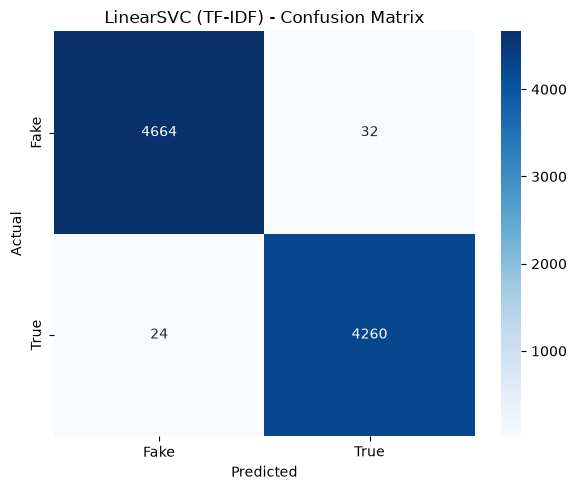

In [ ]:
print("\nClassification Report (LinearSVC + TF-IDF):")
print(classification_report(y_test, svm_tfidf_preds, target_names=["Fake News", "True News"]))

cm = confusion_matrix(y_test, svm_tfidf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "True"], yticklabels=["Fake", "True"])
plt.title("LinearSVC (TF-IDF) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 8. Visualizations

C:\Users\user\AppData\Local\Temp\ipykernel_41616\395015491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='F1 Score', y='Model', palette='viridis')


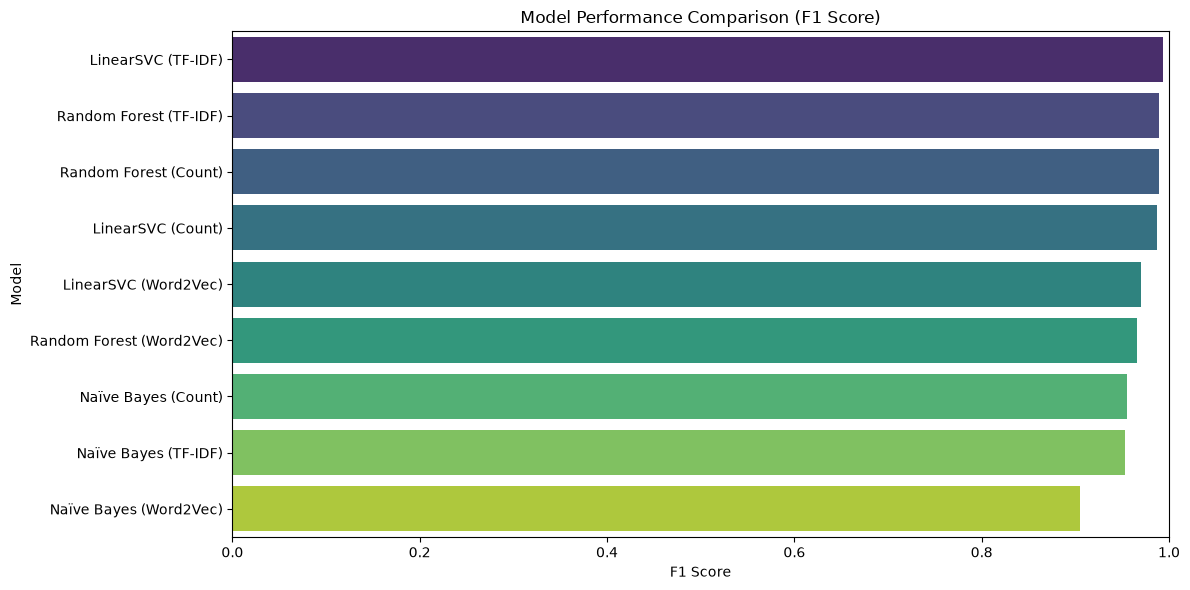

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='F1 Score', y='Model', palette='viridis')
plt.title('Model Performance Comparison (F1 Score)')
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

# 9. External Dataset Validation (fake_data.csv)

In [ ]:
ext_df = pd.read_csv('News_dataset/fake_data.csv')
ext_df['content'] = ext_df['Headline'].fillna('') + ' ' + ext_df['Body'].fillna('')
ext_df['clean_text'] = ext_df['content'].apply(clean_text)

X_ext = ext_df['clean_text']
y_ext = ext_df['Label']

print("External Dataset Size:", len(X_ext))

X_ext_tfidf = tfidf_vectorizer.transform(X_ext)

best_svm = LinearSVC(C=1.0, max_iter=5000)
best_svm.fit(X_train_tfidf, y_train)
ext_preds = best_svm.predict(X_ext_tfidf)

print("\nExternal Dataset Validation Accuracy:", round(accuracy_score(y_ext, ext_preds), 4))
print("External Dataset F1 Score          :", round(f1_score(y_ext, ext_preds), 4))

External Dataset Size: 4009

External Dataset Validation Accuracy: 0.757
External Dataset F1 Score          : 0.6669
